# Schema for files

{
    "$schema": "http://json-schema.org/draft-04/schema#",
    "type": "object",
    "properties": {
        "name": {
            "type": "string"
        },
        "group": {
            "type": "string"
        },
        "metadata": {
            "type": "null"
        },
        "timers": {
            "type": "object",
            "properties": {
                "finished": {
                    "type": "string"
                },
                "started": {
                    "type": "string"
                },
                "vm-running": {
                    "type": "string"
                }
            },
            "required": [
                "finished",
                "started",
                "vm-running"
            ]
        },
        "metrics": {
            "type": "array",
            "items": [
                {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string"
                        },
                        "cpu": {
                            "type": "object",
                            "properties": {
                                "cores": {
                                    "type": "array",
                                    "items": [
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        }
                                    ]
                                },
                                "average": {
                                    "type": "number"
                                }
                            },
                            "required": [
                                "cores",
                                "average"
                            ]
                        },
                        "ram": {
                            "type": "number"
                        },
                        "disk": {
                            "type": "integer"
                        },
                        "timestamp": {
                            "type": "string"
                        }
                    },
                    "required": [
                        "name",
                        "cpu",
                        "ram",
                        "disk",
                        "timestamp"
                    ]
                }
            ]
        }
    },
    "required": [
        "name",
        "group",
        "metadata",
        "timers",
        "metrics"
    ]
}

In [19]:
# Install the required packages
%pip install matplotlib
%pip install Pillow
%pip install scipy
%pip install numpy
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
import os
import json
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib import lines
from scipy.interpolate import make_interp_spline
import pandas as pd

import numpy as np
from itertools import groupby

RESULTS_DIR = 'results'
PLOTS_DIR = 'plots'

In [21]:
# Load results directory and parse out each test
def list_results():
    results = []

    results_files = os.listdir(RESULTS_DIR)
    for file in results_files:
        vmm, group, test, timestamp = file.removesuffix(".json").split('_', 3)
        
        # Parse content as json
        with open(f"{RESULTS_DIR}/{file}", "r") as f:
            content = f.read()
            json_content = json.loads(content)

        results.append({
            'vmm': vmm,
            'group': group,
            'test': test,
            # Parse from 2024-04-03-16-39-37 to datetime
            'timestamp': datetime.strptime(timestamp, "%Y-%m-%d-%H-%M-%S"),
            'data': json_content
        })


    return results       

results = list_results()

print(f"Found {len(results)} results")

Found 22 results


In [22]:
def merge_files(results, node_types):
    def merge_timers(results):
        merged_timers = {}
        for result in results:
            started = result['data']['timers']['started']
            for name, ts_list in result['data']['timers'].items():
                if name not in merged_timers:
                    merged_timers[name] = []

                diff = datetime.fromisoformat(ts_list) - datetime.fromisoformat(started)
                merged_timers[name].append(diff.total_seconds())

        for name, ts_list in merged_timers.items():
            merged_timers[name] = sum(ts_list) / len(ts_list)

        return merged_timers
        
    def combine_metrics(results):
        all_metrics = []
        for result in results:
            started = result['data']['timers']['started']

            for metric in result['data']['metrics']:
                metric['dt'] = (datetime.fromisoformat(metric['timestamp']) - datetime.fromisoformat(started)).total_seconds()
            

            all_metrics += result['data']['metrics']


        # Sort by timestamp
        all_metrics.sort(key=lambda x: x['timestamp'])

        node_groups = {}

        for metric in all_metrics:
            if metric['name'] not in node_groups:
                node_groups[metric['name']] = []

            node_groups[metric['name']].append(metric)

        node_groups = [(name, node_metrics) for name, node_metrics in node_groups.items() if any(node_type in name for node_type in node_types)]

        return node_groups

    return (merge_timers(results), combine_metrics(results))


label = "kubevirt"
group = "create-each-type"
matches = [result for result in results if result['vmm'] == label and result['group'] == group]

merge_files(matches, ["control"])

({'finished': 13.934029125000002, 'started': 0.0, 'vm-running': 9.235322625},
 [('kubevirt-control-1',
   [{'name': 'kubevirt-control-1',
     'cpu': {'cores': [0.0176, 0.0297, 0.0102, 0.01, 0.0204],
      'average': 0.017580000000000002},
     'ram': 0.0993892,
     'disk': 0.008,
     'timestamp': '2024-04-04T14:15:22Z',
     'dt': -11.040395},
    {'name': 'kubevirt-control-1',
     'cpu': {'cores': [0.0252, 0.02, 0.0303, 0.0404, 0.0101],
      'average': 0.0252},
     'ram': 0.099389,
     'disk': 0.008,
     'timestamp': '2024-04-04T14:15:24Z',
     'dt': -9.040395},
    {'name': 'kubevirt-control-1',
     'cpu': {'cores': [0.0352, 0.0306, 0.0202, 0.0392, 0.0505],
      'average': 0.03513999999999999},
     'ram': 0.0993888,
     'disk': 0.012,
     'timestamp': '2024-04-04T14:15:27Z',
     'dt': -6.040395},
    {'name': 'kubevirt-control-1',
     'cpu': {'cores': [0.0152, 0.0303, 0, 0, 0.03],
      'average': 0.015099999999999999},
     'ram': 0.0996391,
     'disk': 0.012,
     

In [23]:
def _plot_all(ax, x_axises, y_axises, timers, vmm):
    min_max_y={}

    # Sort each items in the axises to be increasing
    for i in range(len(x_axises)):
        zip_sorted = sorted(zip(x_axises[i]['data'], y_axises[i]['data']))
        x_axises[i]['data'], y_axises[i]['data'] = zip(*zip_sorted)

    for y_axis in y_axises:
        # Find its corresponding x axis by name
        x_axis = next((x for x in x_axises if x['node'] == y_axis['node']), None)
        # Convert to numpy arrays
        x = np.array(x_axis['data'])
        y = np.array(y_axis['data'])

        # 1. Spline    
        # X_Y_Spline = make_interp_spline(x, y)
        # X_ = np.linspace(x.min(), x.max(), 500)
        # Y_ = X_Y_Spline(X_)
        # ax.plot(X_, Y_)
        
        # 2. Rolling mean
        data = pd.DataFrame({'x': x, 'y': y })
        window_size = 10
        data['y'] = data['y'].rolling(window=window_size, center=True).mean()
        ax.plot(data['x'], data['y'], label=y_axis['label'])

        # 3. Raw
        # ax.plot(x, y, label=y_axis['label'])

        if y_axis['label'] not in min_max_y:
            min_max_y[y_axis['label']] = (y.min(), y.max())
        else:
            min_y, max_y = min_max_y[y_axis['label']]
            min_max_y[y_axis['label']] = (min(min_y, y.min()), max(max_y, y.max()))

    # Plot timers
    for name, val in timers.items():
        # Skip started
        if name == 'started':
            continue            
        
        label = vmm + " " + name
        
        min_y, max_y = min_max_y[y_axis['label']]
        ax.plot([val, val],[min_y, max_y], label=label, linestyle='--')


def _get_x_axises(node_groups):
    x_axises = []

    for name, node_metrics in node_groups:
        x_axis = []
        for metric in node_metrics:
            x_axis.append(metric['dt'])

        x_axises.append({"node": name, "data": x_axis})

    return x_axises

def _get_y_axises(node_groups, utilizations, label):
    y_axises = []

    for utilization in utilizations:
        for name, node_metrics in node_groups:
            y_axis = []
            for metric in node_metrics:
                if utilization == 'cpu':
                    y_axis.append(metric[utilization]['average'])
                else:
                    y_axis.append(metric[utilization])
        
            y_axises.append({"node": name, "data": y_axis, "label": label + " " + utilization})
            
    return y_axises

In [24]:
# Create plots
def plot_results(vmms, group, test, node_types, utiliazations, filename: str = None):
    # Remove any utilization that is not 'cpu', 'ram' or 'disk'
    utiliazations = [utiliazation for utiliazation in utiliazations if utiliazation in ['cpu', 'ram', 'disk']]
    if len(utiliazations) == 0:
        print(f"No valid utilizations found")
        return

    name = f"{group}/{test}"

    fig, ax = plt.subplots()
    ax.set_title(f"{test} ({', '.join(utiliazations)})")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Utilization (%)')

    print(f"Plotting {name} for {', '.join(vmms)}")

    # 1. Find result with group and test, choose latest if multiple
    for vmm in vmms:
        matches = [result for result in results if result['vmm'] == vmm and result['group'] == group and result['test'] == test]
        if len(matches) == 0:
            print(f"No results found for {vmm}/{group}/{test}")
            return
        
        print(f"Found {len(matches)} results for {vmm}/{group}/{test}")
        
        timers, node_groups = merge_files(matches, node_types)
    
        # Extract X axis values
        x_axises = _get_x_axises(node_groups)

        x_timers = timers

        # Extract Y axis values
        label = None
        if len(vmms) > 1:
            label = vmm
            
        y_axises = _get_y_axises(node_groups, utiliazations, label)

        _plot_all(ax, x_axises, y_axises, x_timers, vmm)  
        

    ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.show()

    if filename:
        if not os.path.exists(PLOTS_DIR):
            os.makedirs(PLOTS_DIR)
        fig.savefig(os.path.join(PLOTS_DIR, filename), bbox_inches='tight')


## Create each type

Plotting create-each-type/create-large for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-large
Found 2 results for opennebula/create-each-type/create-large


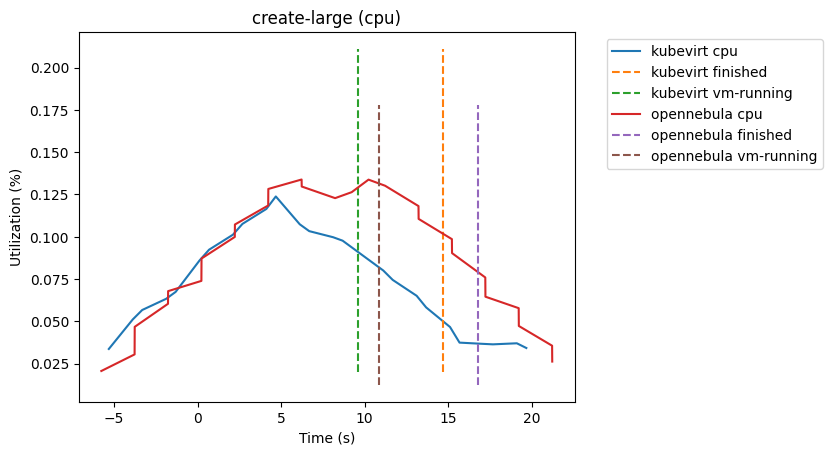

Plotting create-each-type/create-medium for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-medium
Found 2 results for opennebula/create-each-type/create-medium


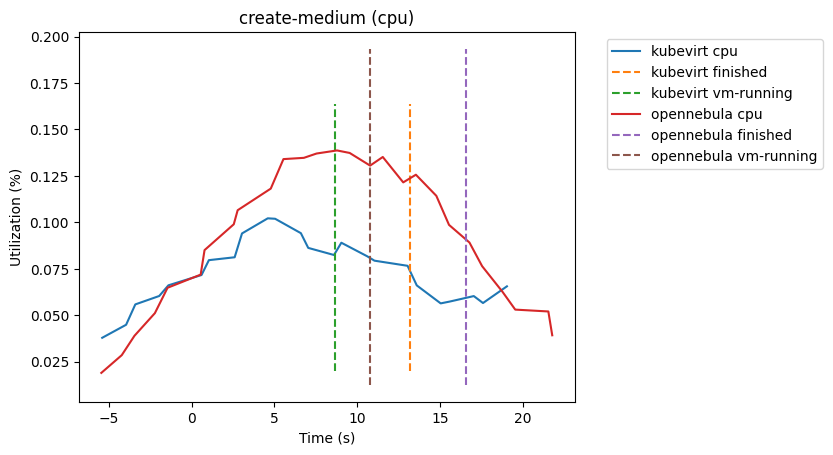

Plotting create-each-type/create-small for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-small
Found 2 results for opennebula/create-each-type/create-small


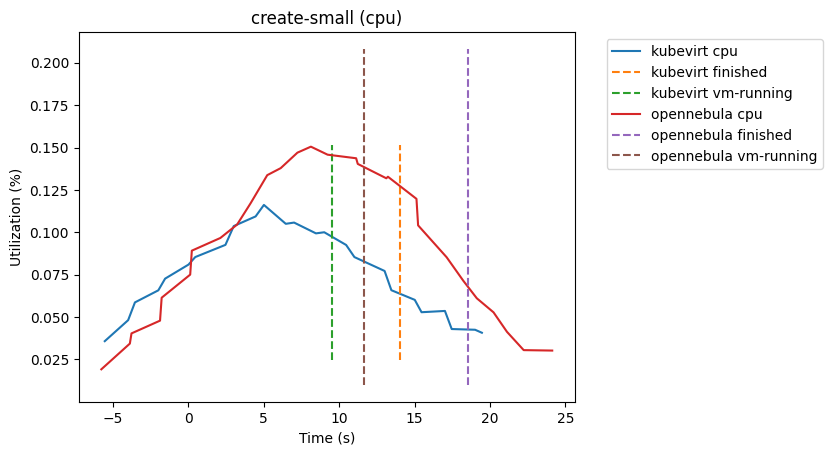

Plotting create-each-type/create-tiny for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-tiny
Found 2 results for opennebula/create-each-type/create-tiny


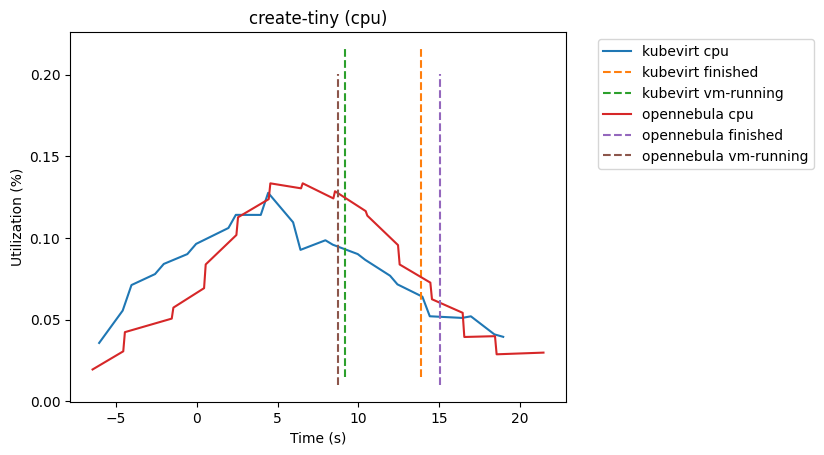

Plotting create-each-type/create-large for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-large
Found 2 results for opennebula/create-each-type/create-large


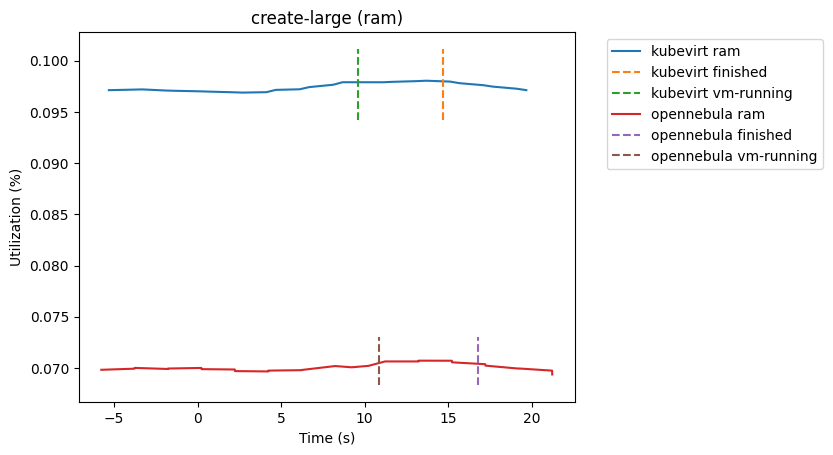

Plotting create-each-type/create-medium for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-medium
Found 2 results for opennebula/create-each-type/create-medium


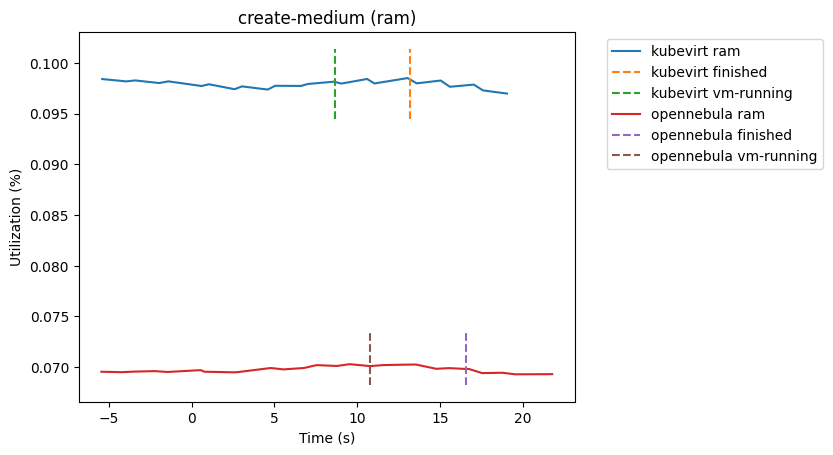

Plotting create-each-type/create-small for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-small
Found 2 results for opennebula/create-each-type/create-small


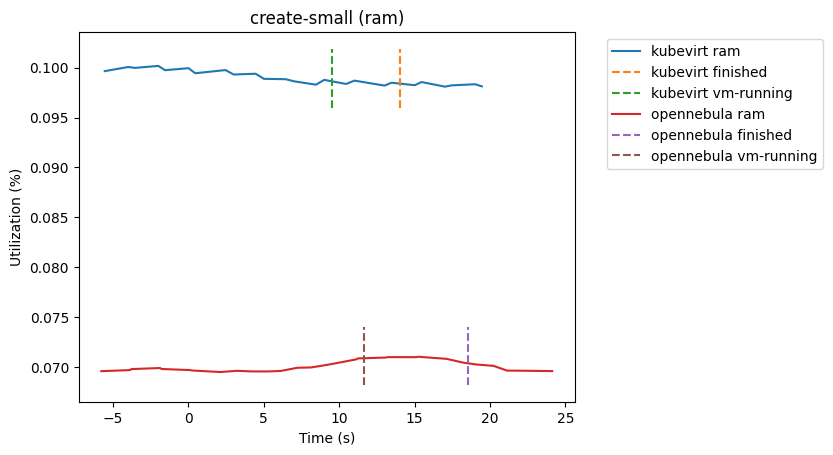

Plotting create-each-type/create-tiny for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-tiny
Found 2 results for opennebula/create-each-type/create-tiny


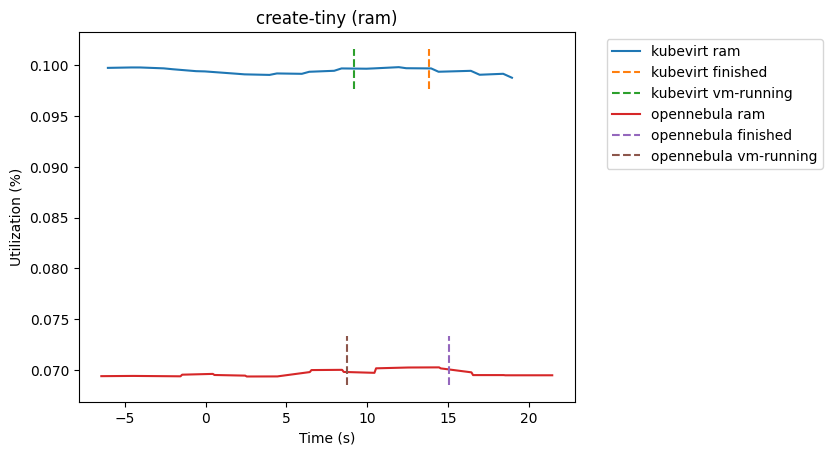

Plotting create-each-type/create-large for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-large
Found 2 results for opennebula/create-each-type/create-large


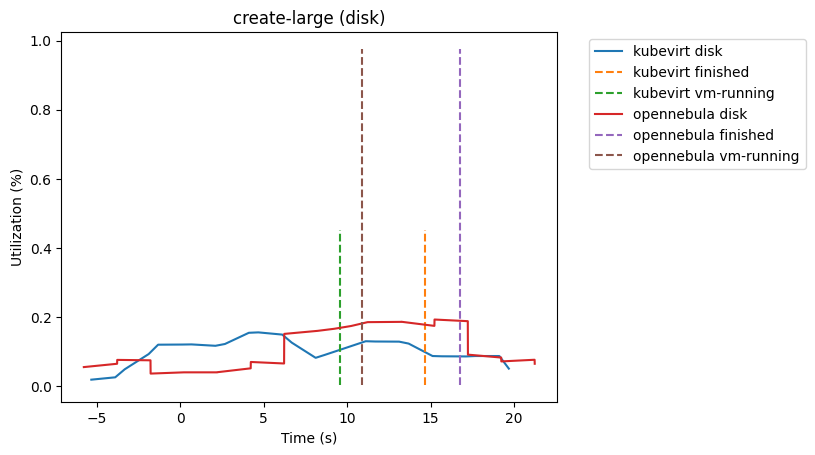

Plotting create-each-type/create-medium for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-medium
Found 2 results for opennebula/create-each-type/create-medium


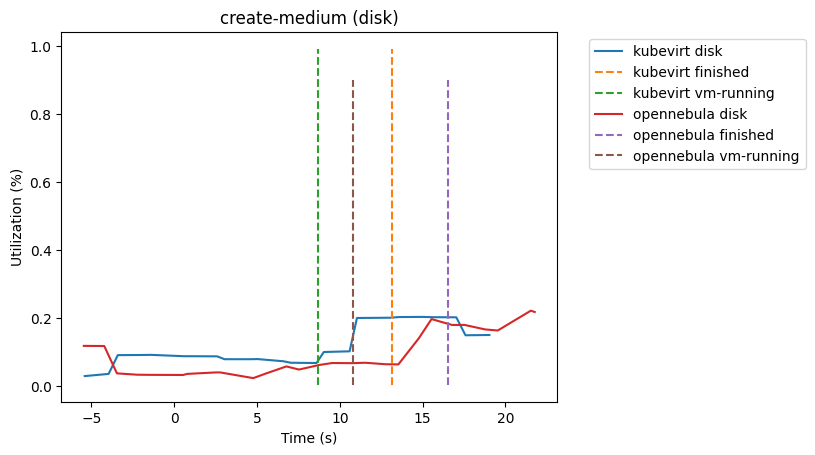

Plotting create-each-type/create-small for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-small
Found 2 results for opennebula/create-each-type/create-small


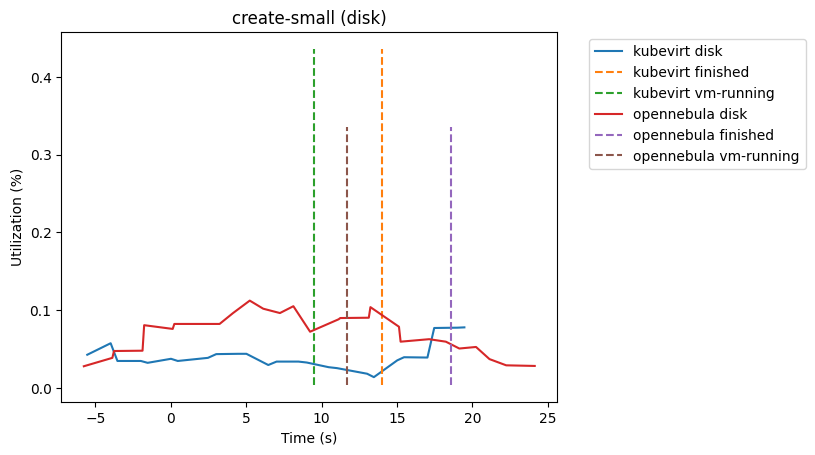

Plotting create-each-type/create-tiny for kubevirt, opennebula
Found 2 results for kubevirt/create-each-type/create-tiny
Found 2 results for opennebula/create-each-type/create-tiny


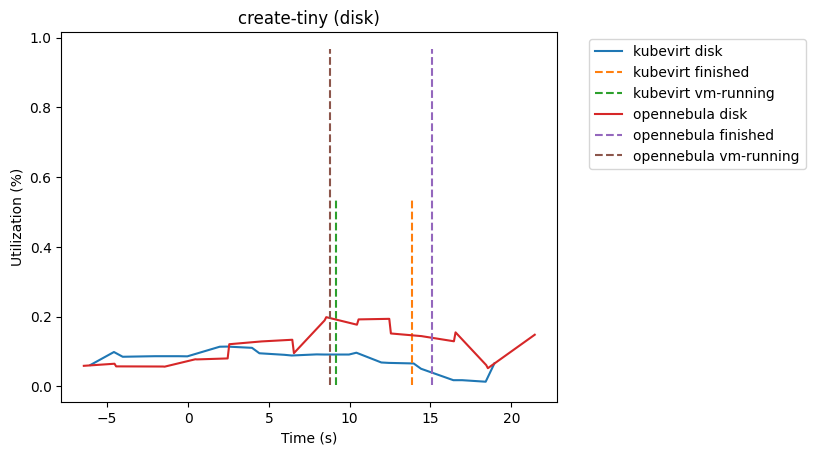

In [25]:
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-large', ['control'], ['cpu'], filename='create-large_cpu.svg')
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-medium', ['control'], ['cpu'], filename='create-medium_cpu.svg')
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-small', ['control'], ['cpu'], filename='create-small_cpu.svg')
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-tiny', ['control'], ['cpu'], filename='create-tiny_cpu.svg')

plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-large', ['control'], ['ram'], filename='create-large_ram.svg')
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-medium', ['control'], ['ram'], filename='create-medium_ram.svg')
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-small', ['control'], ['ram'], filename='create-small_ram.svg')
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-tiny', ['control'], ['ram'], filename='create-tiny_ram.svg')

plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-large', ['control'], ['disk'], filename='create-large_disk.svg')
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-medium', ['control'], ['disk'], filename='create-medium_disk.svg')
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-small', ['control'], ['disk'], filename='create-small_disk.svg')
plot_results(['kubevirt', 'opennebula'],'create-each-type', 'create-tiny', ['control'], ['disk'], filename='create-tiny_disk.svg')



## Create many tiny

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 1 results for kubevirt/scale-cluster/scale-cluster
Found 1 results for opennebula/scale-cluster/scale-cluster


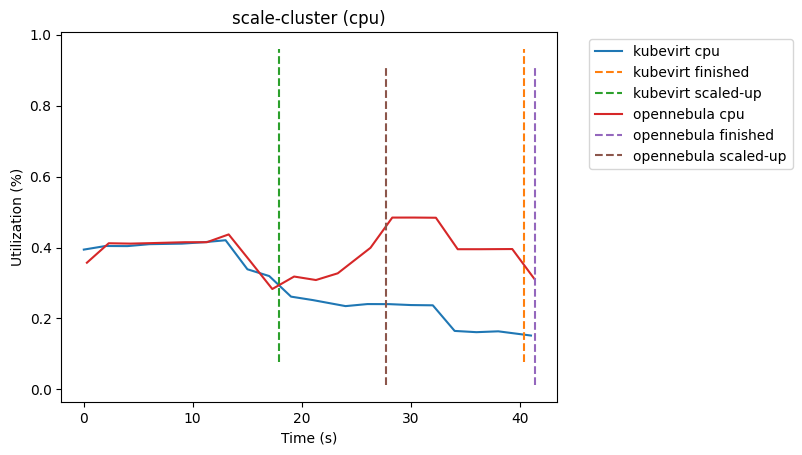

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 1 results for kubevirt/scale-cluster/scale-cluster
Found 1 results for opennebula/scale-cluster/scale-cluster


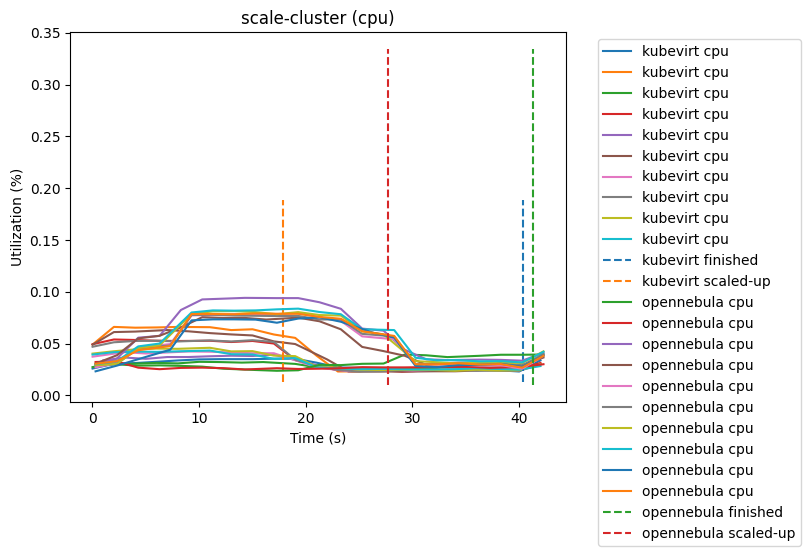

Plotting create-many-tiny-vms/create-many-tiny-vms for kubevirt, opennebula
Found 2 results for kubevirt/create-many-tiny-vms/create-many-tiny-vms
Found 2 results for opennebula/create-many-tiny-vms/create-many-tiny-vms


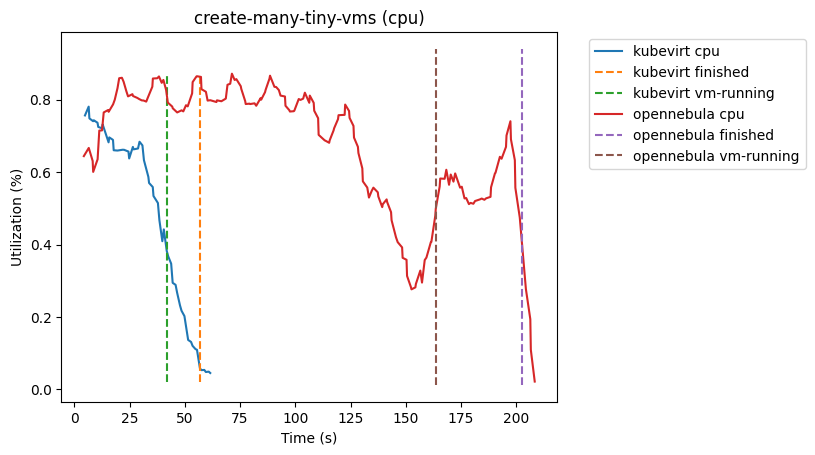

Plotting create-many-tiny-vms/create-many-tiny-vms for kubevirt, opennebula
Found 2 results for kubevirt/create-many-tiny-vms/create-many-tiny-vms
Found 2 results for opennebula/create-many-tiny-vms/create-many-tiny-vms


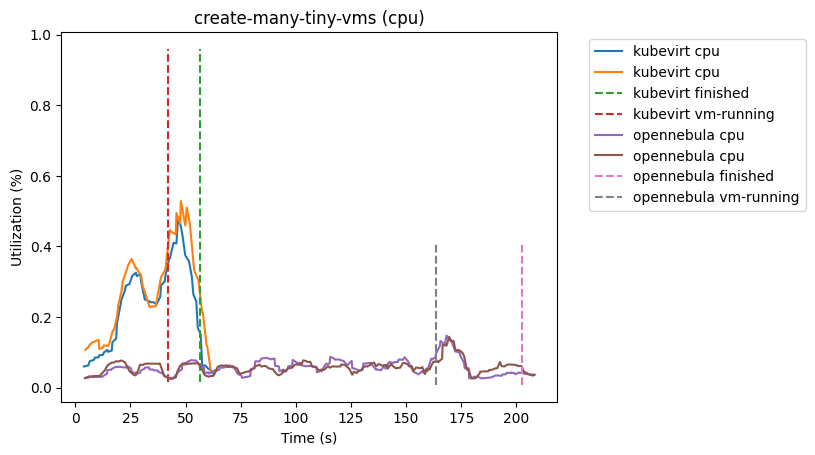

Plotting create-many-tiny-vms/create-many-tiny-vms for kubevirt, opennebula
Found 2 results for kubevirt/create-many-tiny-vms/create-many-tiny-vms
Found 2 results for opennebula/create-many-tiny-vms/create-many-tiny-vms


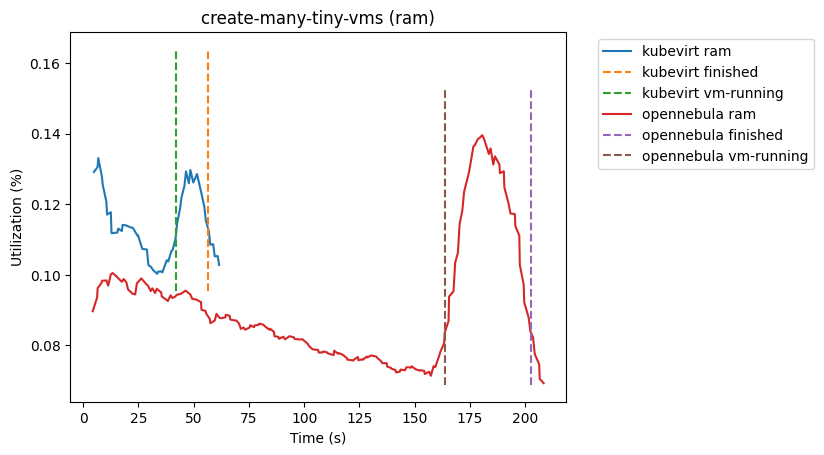

Plotting create-many-tiny-vms/create-many-tiny-vms for kubevirt, opennebula
Found 2 results for kubevirt/create-many-tiny-vms/create-many-tiny-vms
Found 2 results for opennebula/create-many-tiny-vms/create-many-tiny-vms


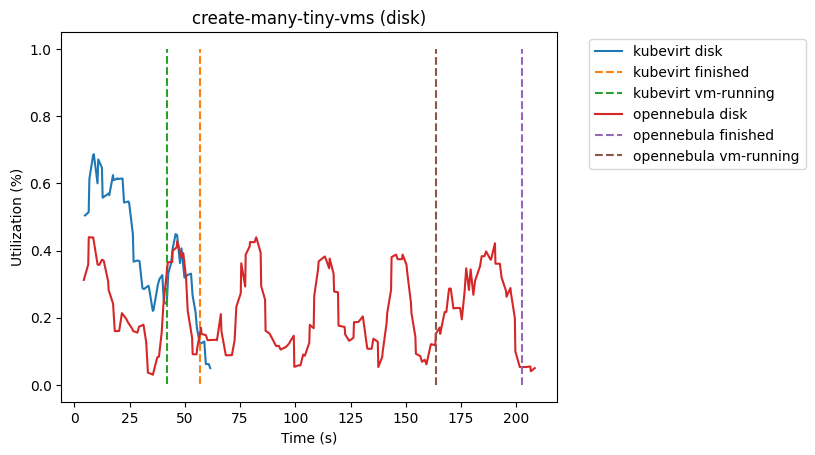

In [26]:
plot_results(['kubevirt', 'opennebula'],'scale-cluster', 'scale-cluster', ['control'], ['cpu'], filename='scale-cluster_cpu.svg')
plot_results(['kubevirt', 'opennebula'],'scale-cluster', 'scale-cluster', ['worker'], ['cpu'], filename='scale-cluster_cpu_worker.svg')


plot_results(['kubevirt', 'opennebula'],'create-many-tiny-vms', 'create-many-tiny-vms', ['control'], ['cpu'], filename='create-many-tiny-vms_cpu.svg')
plot_results(['kubevirt', 'opennebula'],'create-many-tiny-vms', 'create-many-tiny-vms', ['worker'], ['cpu'], filename='create-many-tiny-vms_cpu_worker.svg')


plot_results(['kubevirt', 'opennebula'],'create-many-tiny-vms', 'create-many-tiny-vms', ['control'], ['ram'], filename='create-many-tiny-vms_ram.svg')
plot_results(['kubevirt', 'opennebula'],'create-many-tiny-vms', 'create-many-tiny-vms', ['control'], ['disk'], filename='create-many-tiny-vms_disk.svg')
